Step size (h): 0.01
Solution may not be Entirely Stable ;)

Step size (h): 0.05
Solution may not be Entirely Stable ;)

Step size (h): 0.1
Solution may not be Entirely Stable ;)

Step size (h): 0.5
Solution may not be Entirely Stable ;)



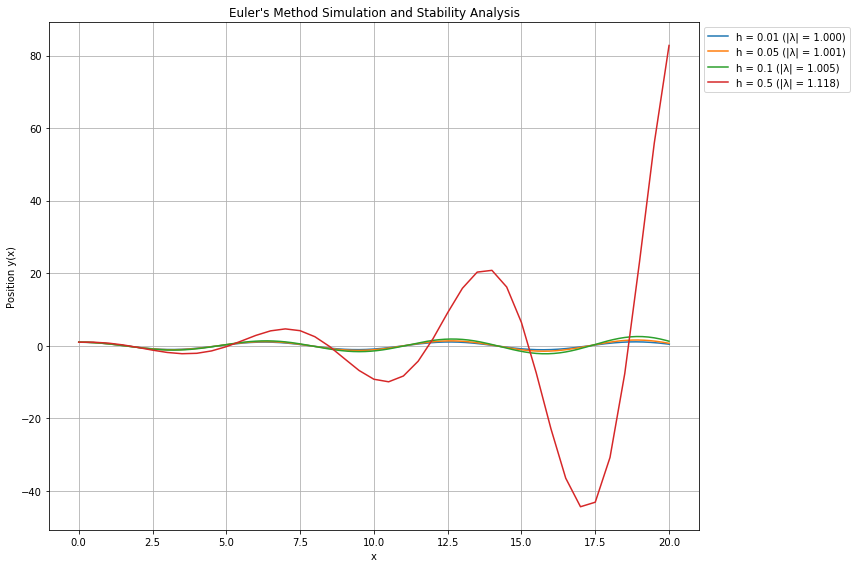

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
k = 1.0        # Constant in the equation
h_values = [0.01, 0.05, 0.1, 0.5]  # Different step sizes to test
x_start = 0
x_end = 20     # Extended time interval to clearly see instability growth
y_0 = 1.0
v_0 = 0.0

# Prepare the plot
plt.figure(figsize=(12, 8))

for h in h_values:
    # 1. Construct the coefficient matrix for Euler's Method
    # [ y_{n+1} ] = [  1    h ] [ y_n ]
    # [ v_{n+1} ]   [ -hk   1 ] [ v_n ]
    A = np.array([
        [1, h],
        [-h * k, 1]
    ])
    
    # 2. Compute the eigenvalues using built-in functions
    eigenvalues = np.linalg.eigvals(A)
    
    # 3. Check stability: get the maximum magnitude of the eigenvalues
    max_magnitude = np.max(np.abs(eigenvalues))
    
    # Output the required terminal text
    print(f"Step size (h): {h}")
    if max_magnitude < 1:
        print("Solution is Stable\n")
    else:
        print("Solution may not be Entirely Stable ;)\n")
        
    # 4. Simulate the numerical solution
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(x_values)):
        # Using matrix multiplication to update the state
        current_state = np.array([y_values[i - 1], v_values[i - 1]])
        next_state = A.dot(current_state)
        
        y_values[i] = next_state[0]
        v_values[i] = next_state[1]
        
    # 5. Visualize the results
    plt.plot(x_values, y_values, label=f'h = {h} (|λ| = {max_magnitude:.3f})')

# Format and display the plot
plt.xlabel('x')
plt.ylabel('Position y(x)')
plt.title('Euler\'s Method Simulation and Stability Analysis')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()